splitting text into individual names using splitlines() and opening it in read mode

In [ ]:
words = open('names.txt','r').read().splitlines()

viewing the words

In [ ]:
words

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [ ]:
import torch

creating a 28,28(to include the start and end points within the name)

In [ ]:
N = torch.zeros((28, 28), dtype=torch.int32)

sorting the characters in the words and storing them in a string to index(a -> 0) and an index to string(0 ->a)

also adding a stoi for the starting character instead of having both the start and end dots for the model to understand when the word to be generated starts and when it ends

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

for all words to be generated we make a list of chs where we join the start and end points of the word in the format of .character. but instead of s and e we maintain a dot

In [ ]:
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1,ix2] += 1

using this for loop we can generate a character followed by another character according the the probability of it following it up by using ix1 and ix2 and storing it in N as a pair of ix1,ix2

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


using matplotlib we can plot the number of times each letter by followed by another in a 27 by 27 matrix

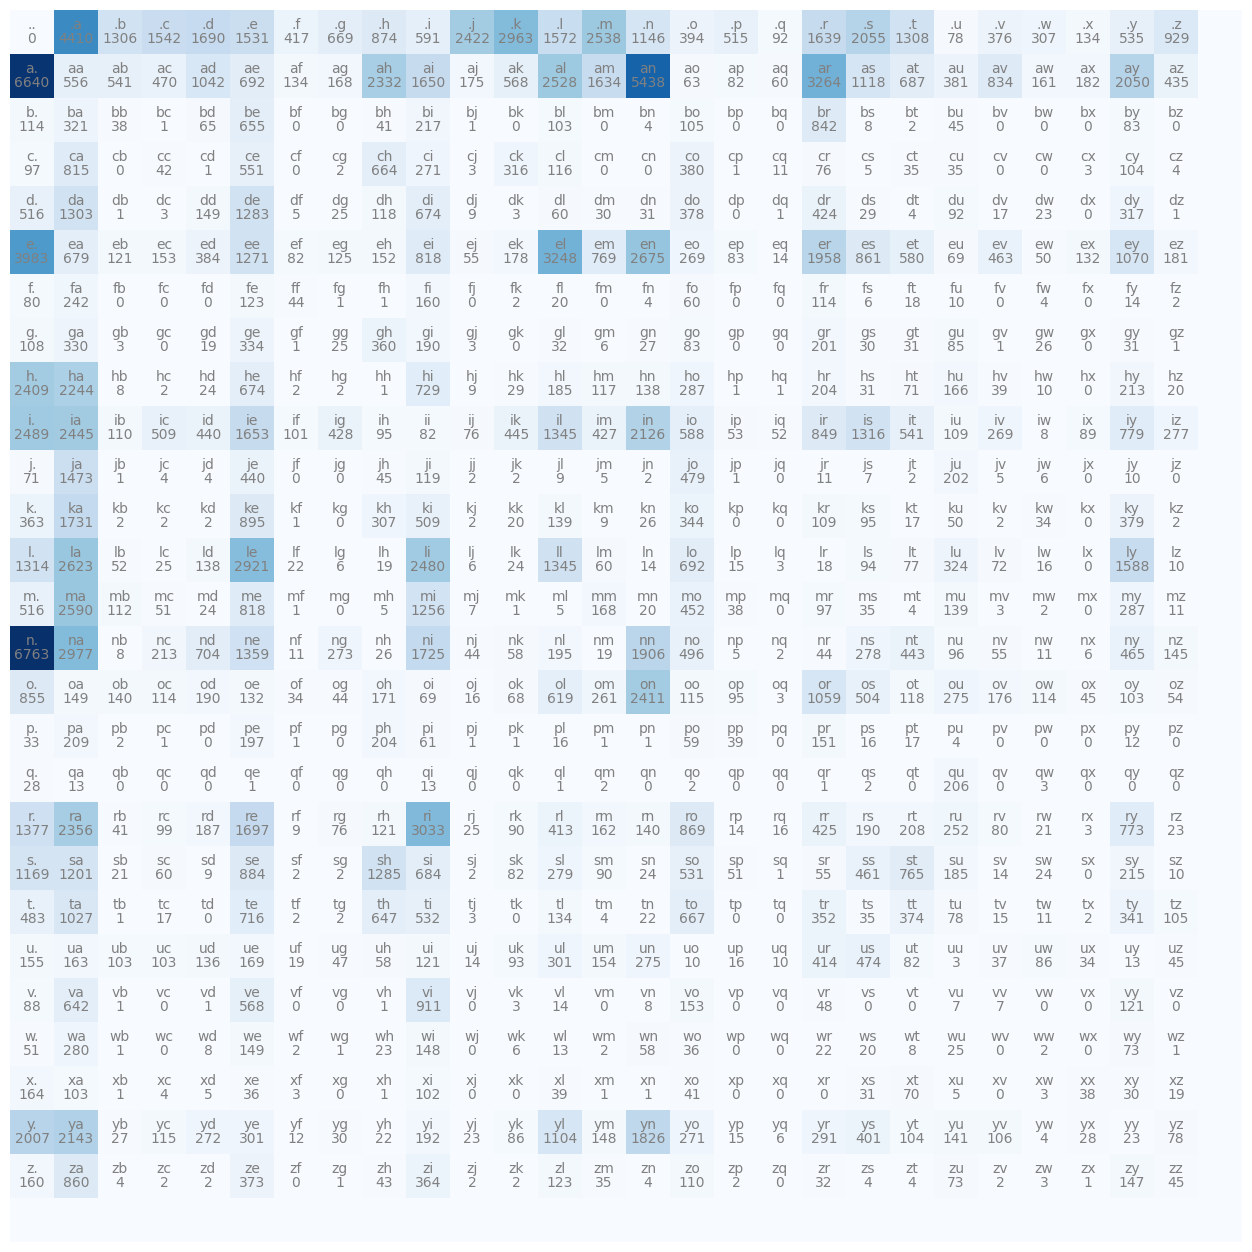

In [ ]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
texts=[]
for i in range(27):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha='center', va='bottom',color='gray')
    plt.text(j, i, N[i,j].item(), ha='center', va='top',color='gray')
plt.axis('off');


N contains the probability of each letter following something else as a number which is in the integar format.

We can now draw samples based on the probabilities in hand by creating a probability distribution which the model can follow when drawing samples.

Create a matrix P to store all the probabilities associated with chr1 following up chr2

add a count of 1 to N for model smoothing so invalid names dont show infinite negative log likelihood


In [ ]:
P = (N+1).float()
P = P / P.sum(1, keepdim=True)

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  out = []
  ix = 0
  while True:
    p = P[ix]

    ix = torch.multinomial(p, num_samples=1, replacement= True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))


junide.
janasah.
p.
cony.
a.


we use prob to evaluate the probability that the model assigns to each of the bigrams which is summarized in the matrix P which is the probability distribution we used

next to evaluate loss we can evaluate the likelihood which the product of all the probabilities which should be high for a well performing model

In this case because the individual probabilities are very small the product of the probability would be a small number. For this log of the likelihood is used

Log is a monotonic function which means the more numbers are near 1 the log prob would be near 0 and the more they are towards 0 the more it will be negative

log likelihood is convinient because it is the addition of logs of individual probabilities

log(a*b*c) = log(a) + log(b) + log(c)

the main aim of loss functions is to minimize things for less loss.

log likelihood is 0 if probs are 1 and it is more and more negative if probs are negative, hence we use a negative log likelihood which inverts this

negative log likelihood is better because the lowest it can get is zero and the higher it can get the worse our predictions are which makes it an idea loss function

In [ ]:
log_likelihood = 0.0
n = 0
#we can also test the probability for a specific word

for w in words[:3]:
#for w in ["harsh"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
      ix1 = stoi[ch1]
      ix2 = stoi[ch2]
      prob = P[ix1, ix2]
      n += 1
      logprob = torch.log(prob)
      log_likelihood += logprob
      #print(f'{ch1}{ch2}: {prob:.4f}: {logprob:.4f}')
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll}')
print(f'{nll/n}')



log_likelihood=tensor(-38.8102)
38.810203552246094
2.425637722015381


PART 2 : NEURAL NETWORK

First we create two variables which will act as the parameters we feed the network which are xs the inputs and ys are the ones we want to predict

we cannot feed the network the normal xs and ys we have created as it does not just take in integars as inputs

hence we need to do one hot encoding which for example if we want to input the integar 13 then it will create a vector of 0s with the 13th element as 1 to represent our input number which can be fed into the neural network

we can do this with torch.functional.one_hot

In [ ]:
import torch.nn.functional as F

In [ ]:
xs, ys = [], []
for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    print(ch1,ch2)
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)


. e
e m
m m
m a
a .


this shows that when the input for the neural network will be 0 the desired output should be 5

In [ ]:
xs, ys

(tensor([ 0,  5, 13, 13,  1]), tensor([ 5, 13, 13,  1,  0]))

we create a xenc which shows the one hot encodded values for xs and we can see that for (0,5,13,13,1) for 0 the first bit from the total 27 classes is turned on and so are the bits for (5,13,13,1) and the shape of it is 5x27

because we dont want to input integars into our network we switch the dtype of xenc to float manually

In [ ]:
xenc = F.one_hot(xs, num_classes=27).float()
xenc, xenc.shape

(tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.]]),
 torch.Size([5, 27]))

now we can create a single neuron with some weight

we set W as 27x1 values drawn from a normal distribution

now we use xenc as the inputs and W as weights and multiply using @ which is used for matrix multiplication in pytorch

this shows us the firing rate of all 27 neurons we created with W on all the 5 examples we had for our first name that we fed into the model

In [ ]:
W = torch.randn((27,27))
xenc @ W, (xenc @ W).shape

(tensor([[-5.6284e-01,  2.9851e-01,  6.8027e-01,  3.9404e-02, -3.6843e-01,
          -1.2133e+00,  5.1471e-01, -1.4210e+00, -1.0709e+00, -5.2120e-01,
          -1.2358e+00, -5.1055e-01, -5.5945e-03, -3.0313e-02,  8.6915e-01,
          -7.4413e-01, -1.1800e+00, -5.8927e-01, -1.3372e+00, -4.6181e-01,
           1.2251e+00, -2.4747e-01, -1.2108e+00, -2.1282e+00,  1.4285e+00,
          -1.0245e+00, -4.7923e-01],
         [-1.2841e+00, -1.9635e+00,  4.3155e-01,  1.3605e+00, -5.8516e-01,
           4.4006e-01,  2.9885e-01, -1.4012e+00,  1.8538e+00,  8.3970e-01,
          -1.0781e+00, -1.0281e+00,  4.5385e-01, -1.4866e+00, -2.9705e-01,
           2.6749e-02, -7.9666e-01, -1.4046e-01, -2.4268e-01,  8.3899e-01,
           6.5365e-02, -1.9540e+00,  3.2431e-01, -3.2423e-01, -7.2507e-01,
           7.6246e-02, -1.0048e-01],
         [-5.9154e-01, -7.6825e-02,  1.3628e+00, -2.0959e-01, -9.9061e-01,
           2.2999e+00, -4.4779e-01,  4.6024e-01,  8.3910e-01, -8.7160e-04,
          -3.2840e-02, -7.

now we have some positive and negative numbers which are the outputs of the neural network but we need to output probability distribution for 27 characters to follow up the character initially fed into it as an input

in the first part we had counts to show how many times a certain character follows up an initial character but in this case we dont have counts so we create log counts(logits) by exponentiating our (xenc @ W) to give us numbers which are greater than 0 because exponent of negative numbers makes them  positive and near 1 and for positive numbers it makes them even greater than what they were

here counts is equivalent to the N matrix of counts we had in part 1

for probabilities we had normalised the counts so that they all add up to 1


In [ ]:
logits = xenc @ W
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob

tensor([[0.0219, 0.0519, 0.0760, 0.0400, 0.0266, 0.0114, 0.0644, 0.0093, 0.0132,
         0.0228, 0.0112, 0.0231, 0.0383, 0.0373, 0.0917, 0.0183, 0.0118, 0.0213,
         0.0101, 0.0242, 0.1310, 0.0300, 0.0115, 0.0046, 0.1605, 0.0138, 0.0238],
        [0.0085, 0.0043, 0.0470, 0.1191, 0.0170, 0.0474, 0.0412, 0.0075, 0.1951,
         0.0708, 0.0104, 0.0109, 0.0481, 0.0069, 0.0227, 0.0314, 0.0138, 0.0265,
         0.0240, 0.0707, 0.0326, 0.0043, 0.0423, 0.0221, 0.0148, 0.0330, 0.0276],
        [0.0128, 0.0215, 0.0907, 0.0188, 0.0086, 0.2314, 0.0148, 0.0368, 0.0537,
         0.0232, 0.0225, 0.0111, 0.0395, 0.1307, 0.0357, 0.0063, 0.0121, 0.0150,
         0.0653, 0.0051, 0.0180, 0.0698, 0.0062, 0.0041, 0.0043, 0.0116, 0.0304],
        [0.0128, 0.0215, 0.0907, 0.0188, 0.0086, 0.2314, 0.0148, 0.0368, 0.0537,
         0.0232, 0.0225, 0.0111, 0.0395, 0.1307, 0.0357, 0.0063, 0.0121, 0.0150,
         0.0653, 0.0051, 0.0180, 0.0698, 0.0062, 0.0041, 0.0043, 0.0116, 0.0304],
        [0.0545, 0.0265,

In [ ]:
nlls = torch.zeros(5)
for i in range(5):
  #ith bigram:
  x = xs[i].item() #input character index
  y = ys[i].item() #label character index
  print('---------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x}, {y})')
  print('input to the neural network : ', x)
  print('output probabilities from the neural network :', prob[i])
  print('label which is the actual next character :', y)
  p = prob[i,y]
  print('probability assigned by the network to the correct character :', p.item())
  logp = torch.log(p)
  print(' log likelihood: ', logp.item())
  nll = -logp
  print('negative log likelihood :', nll.item())
  nlls[i] =  nll

print('=========')
print('average negative log likelihood, i.e. loss = ', nlls.mean().item())



---------
bigram example 1: .e (indexes 0, 5)
input to the neural network :  0
output probabilities from the neural network : tensor([0.0219, 0.0519, 0.0760, 0.0400, 0.0266, 0.0114, 0.0644, 0.0093, 0.0132,
        0.0228, 0.0112, 0.0231, 0.0383, 0.0373, 0.0917, 0.0183, 0.0118, 0.0213,
        0.0101, 0.0242, 0.1310, 0.0300, 0.0115, 0.0046, 0.1605, 0.0138, 0.0238])
label which is the actual next character : 5
probability assigned by the network to the correct character : 0.011433000676333904
 log likelihood:  -4.471251487731934
negative log likelihood : 4.471251487731934
---------
bigram example 2: em (indexes 5, 13)
input to the neural network :  5
output probabilities from the neural network : tensor([0.0085, 0.0043, 0.0470, 0.1191, 0.0170, 0.0474, 0.0412, 0.0075, 0.1951,
        0.0708, 0.0104, 0.0109, 0.0481, 0.0069, 0.0227, 0.0314, 0.0138, 0.0265,
        0.0240, 0.0707, 0.0326, 0.0043, 0.0423, 0.0221, 0.0148, 0.0330, 0.0276])
label which is the actual next character : 13
probabili